In [100]:
import rysynth as R
import math, time
import numpy as np
from qiskit import ClassicalRegister, QuantumCircuit, QuantumRegister
from qiskit import transpile
import numpy as np
import matplotlib.pyplot as plt
from qiskit_aer.noise import (NoiseModel, QuantumError, ReadoutError,
    pauli_error, depolarizing_error, thermal_relaxation_error)
#import bitstring
from qiskit_aer import AerSimulator

In [101]:
#iQPE, but with Ry as Unitary, i.e. log. qubit starts in |0>, then apply Unitary, then just readout in computational basis. This is similar to the new iQPE scheme, where only one log. qubit is required.

n = 15
angle = np.linspace(0,1,n+2)
angle = np.delete(angle, [n+1])
angle = np.delete(angle, [0])
angle = [i/2 for i in angle]

print("Angles of sqrt(U) that we actually implement via iQPE: ", angle)

Angles of sqrt(U) that we actually implement via iQPE:  [np.float64(0.03125), np.float64(0.0625), np.float64(0.09375), np.float64(0.125), np.float64(0.15625), np.float64(0.1875), np.float64(0.21875), np.float64(0.25), np.float64(0.28125), np.float64(0.3125), np.float64(0.34375), np.float64(0.375), np.float64(0.40625), np.float64(0.4375), np.float64(0.46875)]


In [109]:
def show(gates, head=30):
    for i, g in enumerate(gates[:head]):
        args = ', '.join('q%d' % q for q in g[1:])
        print('%4d  %-4s %s' % (i, g[0], args))
    if len(gates) > head:
        print('      ...  (%d more gates)' % (len(gates) - head))

lists = []

for THETA in angle:
    EPS = 1e-2
    t0  = time.time()
    res = R.synthesize_ry(2*np.pi*THETA, EPS)
    dt  = time.time() - t0

    gates = res['gates']
    print('done in %.2f s' % dt)
    print('lde k          :', res['k'], ' (~3*log2(1/eps) = %.1f)' % (3*math.log2(1/EPS)))
    print('gate count     :', res['counts'])
    print('rounded column : v0 =', res['v0'])
    print('                 v1 =', res['v1'])

    lists.append(gates)

# with open("htoff15_TEST_1e-2.txt", "w") as f:
#     for row in lists:
#         line = ",".join("_".join(map(str, item)) for item in row)
#         f.write(line + "\n")

done in 0.01 s
lde k          : 20  (~3*log2(1/eps) = 19.9)
gate count     : {'X': 60, 'CCX': 95, 'H': 20, 'total': 175}
rounded column : v0 = [1019, 101, 3, 2, 1, 0, 0, 0]
                 v1 = [-101, 1019, -2, 3, 0, 1, 0, 0]
done in 0.01 s
lde k          : 17  (~3*log2(1/eps) = 19.9)
gate count     : {'CCX': 72, 'X': 44, 'H': 17, 'total': 133}
rounded column : v0 = [355, 71, 2, 1, 1, 0, 0, 0]
                 v1 = [-71, 355, -1, 2, 0, 1, 0, 0]
done in 0.01 s
lde k          : 21  (~3*log2(1/eps) = 19.9)
gate count     : {'X': 66, 'H': 23, 'CCX': 114, 'total': 203}
rounded column : v0 = [1388, 413, 6, 1, 1, 1, 0, 0]
                 v1 = [-413, 1388, -1, 6, -1, 1, 0, 0]
done in 0.01 s
lde k          : 21  (~3*log2(1/eps) = 19.9)
gate count     : {'X': 48, 'H': 25, 'CCX': 103, 'total': 176}
rounded column : v0 = [1340, 549, 11, 5, 2, 1, 0, 0]
                 v1 = [-549, 1340, -5, 11, -1, 2, 0, 0]
done in 0.01 s
lde k          : 21  (~3*log2(1/eps) = 19.9)
gate count     : {'X': 62, 'H'

In [110]:
with open("htoff15_TEST_1e-2.txt", "r") as f:
    htoff_decomp = [
        [tuple(item.split("_")[0:1] + [int(x) for x in item.split("_")[1:]])
         for item in line.strip().split(",")]
        for line in f
    ]

In [111]:
print(lists[0][0])
# htoff_decmop.reverse()
print(htoff_decomp[0][1])
for i in htoff_decomp[0]:
    if i[0] == "X":
        print(i[1])
    elif i[0] == "H":
        print(i[1])
    elif i[0] == "CCX":
        print(i[1],i[2],i[3])

('X', 1)
('CCX', 0, 1, 2)
1
0 1 2
1
0
0 1 2
2
0 2 1
2
0 1 2
2
2
0 2 1
2
0
1 2 0
0
0 1 2
1 2 0
1
1 2 0
1
0 2 1
0 1 2
2
2
0 2 1
2
1
1 2 0
1
2
0 1 2
0 2 1
1
1 2 0
1
0 1 2
2
0 1 2
0 2 1
1
1 2 0
1
0 2 1
0 1 2
0 2 1
2
0 1 2
0 2 1
1
1 2 0
1
0 1 2
2
0 1 2
0 2 1
1
1 2 0
1
0 2 1
0 1 2
0 2 1
0 1 2
2
0 1 2
0 2 1
1
1 2 0
1
0 2 1
0 1 2
1 2 0
0 1 2
0
0 1 2
1 2 0
1
1 2 0
1
0 2 1
0 1 2
2
2
1
1 2 0
2
1
0 2 1
2
2
1
1 2 0
2
1
0 1 2
0 2 1
0 1 2
2
2
0 2 1
2
1
1 2 0
1
2
2
0 2 1
2
1 2 0
0
0 1 2
0
0
0 1 2
1 2 0
1
1 2 0
1
0 2 1
0 1 2
1
0
0 1 2
0 2 1
0 1 2
0
2
1 2 0
2
1
0 1 2
0 2 1
1 2 0
0 2 1
1
1 2 0
1
0 2 1
0 1 2
0
0 1 2
0 2 1
1 2 0
0 1 2
2
2
1
1 2 0
2
1
0 1 2
0 2 1
0 1 2
0
0 2 1
0
1
0 1 2
0 2 1
1
1 2 0
1
0 2 1
0 1 2
0 2 1
1 2 0
0 2 1
0
0 1 2
0 2 1
1
1 2 0
1
0 2 1
0 1 2


In [115]:
#First we need to define necessary functions for iQPE

def gates(qc: QuantumCircuit):
    hmm = dict(qc.count_ops())
    hmm["reset"] = 0
    hmm["measure"] = 0
    hmm["if_else"] = 0
    return sum(hmm.values())

def U(qc: QuantumCircuit, pos: int, decomp: list, index = 0):
    for i in decomp[index]:
        if i == "h":
            qc.h(pos)
        if i == "z":
            qc.z(pos)
        if i == "s":
            qc.s(pos)
        if i == "sdg":
            qc.sdg(pos)
        if i == "t":
            qc.t(pos)
        if i == "tdg":
            qc.tdg(pos)

def cu(qc: QuantumCircuit, index=0):
    U(qc, pos=0, decomp=unit, index=index)
    U(qc, pos=1, decomp=unit, index=index)
    qc.cx(0,1)    
    U(qc, pos=1, decomp=adj, index=index)
    qc.cx(0,1) 

def U_htoff(qc: QuantumCircuit, index=0):
    # qc.reset((1,2))
    with open("htoff15_TEST_1e-2.txt", "r") as f:
        htoff_decomp = [
            [tuple(item.split("_")[0:1] + [int(x) for x in item.split("_")[1:]])
            for item in line.strip().split(",")]
            for line in f
        ]
    # htoff_decomp.reverse()
    for i in htoff_decomp[index]:
        if i[0] == "X":
            qc.x(i[1])
        elif i[0] == "H":
            qc.h(i[1])
        elif i[0] == "Z":
            qc.z(i[1])
        elif i[0] == "CCX":
            qc.ccx(i[1],i[2],i[3])
        else:
            print("MISSING GATE")

def cu_ramsey(qc: QuantumCircuit, index=0):
    U(qc, pos=0, decomp=unit, index=index)
    U(qc, pos=1, decomp=unit, index=index)

def convert(bin: str):                  #konvertiert den bitstring in decimal, e.g. 0110 = 0.375
    k = list(bin)
    a = [int(i) for i in k]
    n = 0
    for i in range(len(a)):
        if a[i] == 1:
            n += 1/2**(i+1)
    return n

def iQPE_ry_ramsey(shots: int, noise = 0, bias = 0):                 #so wie iQPE, aber ohne diese kack for loop, err bar ist dann theoretisch nicht 100% korrekt
    angles = np.linspace(0,1,17)[1:16][1::2]
    p = noise
    p_x, p_z = 0, 0
    if bias > 0:
        p_x += (bias/(1+bias))*p
        p_z += p - p_x
    elif bias < 0:
        p_z += (np.abs(bias)/(1+np.abs(bias)))*p
        p_x += p - p_z
    else:
        p_x += p/2
        p_z += p/2
        
    p_error = pauli_error([["X",p_x],["I",1-p],["Z",p_z]])
    p_error_2 = pauli_error([["XI",p_x/2],["IX",p_x/2],["II",1-p],["ZI",p_z/2],["IZ",p_z/2]])

    noise_model = NoiseModel()
    noise_model.add_all_qubit_quantum_error(p_error, ['x', "z", 'h', "s", "sdg", "tdg", "t", "id"])  # Apply to single-qubit gates
    noise_model.add_all_qubit_quantum_error(p_error_2, ['cx'])  # Apply to 2-qubit gates

    y_list = []
    gatecount = 0

    qr = QuantumRegister(3,"q")
    cbits = ClassicalRegister(3*7,"c")
    qc = QuantumCircuit(qr, cbits)
    for o in range(7):
        for k in range(3):
            for _ in range(2**(2-k)):
                U_htoff(qc, index=2*o+1)
                U_htoff(qc, index=2*o+1)
                # U_htoff(qc, index=2*o+1)
                # U_htoff(qc, index=2*o+1)
            if k == 1:
                with qc.if_test((0+3*o,1)):
                    qc.ry(-np.pi/2, 0)
            else:
                with qc.if_test((0+3*o,1)):
                    qc.ry(-np.pi/4, 0)
            with qc.if_test((1+3*o,1)):
                qc.ry(-np.pi/2, 0)
            qc.measure(0,k+3*o)
            qc.reset(0), qc.reset(1), qc.reset(2)
    sim = AerSimulator()
    job = sim.run(qc, noise_model = noise_model, shots=shots)
    gatecount += gates(qc)
    result = job.result()
    counts = result.get_counts()

    # print("Unoptimized circuit: ", dict(qc.count_ops()))
    # print("Transpiled circuit: ", dict(new_qc.count_ops()))

    for _, val in enumerate(list(counts.keys())):
        bruh = []           #temp list of the y_values aka the performance
        bitstring = val
        counter = counts[val]

        angles_measured = []
        for o in range(len(angles)):
            angles_measured.append(convert(bitstring[3*o:3*o+3]))

        angles_measured = angles_measured[::-1]
        for o in range(len(angles)):
            bruh.append(np.abs(angles_measured[o]-angles[o]))

        for _ in range(counter):
            y_list.append(np.mean(bruh))
    
    y, err = np.mean(y_list), np.std(y_list)/np.sqrt(shots)
    
    return y, err, gatecount/(3*len(angles))

def iQPE15_ry(shots: int, noise: int, bias = 0):                 #so wie iQPE, aber ohne diese kack for loop, err bar ist dann theoretisch nicht 100% korrekt
    angles = np.linspace(0,1,17)[1:16]
    p = noise
    p_x, p_z = 0, 0
    if bias > 0:
        p_x += (bias/(1+bias))*p
        p_z += p - p_x
    elif bias < 0:
        p_z += (np.abs(bias)/(1+np.abs(bias)))*p
        p_x += p - p_z
    else:
        p_x += p/2
        p_z += p/2
    p_error = pauli_error([["X",p_x],["I",1-p],["Z",p_z]])
    p_error_2 = pauli_error([["XI",p_x/2],["IX",p_x/2],["II",1-p],["ZI",p_z/2],["IZ",p_z/2]])

    noise_model = NoiseModel()
    noise_model.add_all_qubit_quantum_error(p_error, ['x', "z", 'h', "s", "sdg", "tdg", "t", "id"])  # Apply to single-qubit gates
    noise_model.add_all_qubit_quantum_error(p_error_2, ['cx'])  # Apply to 2-qubit gates

    y_list = []
    gatecount = 0

    qr = QuantumRegister(2,"q")
    cbits = ClassicalRegister(3*15,"c")
    qc = QuantumCircuit(qr, cbits)
    for o in range(15):
        for k in range(3):
            qc.id(0), qc.id(1)
            qc.h(0), qc.x(1)
            for i in range(2**(2-k)):
                U(qc, pos=0, decomp=unit, index=o), U(qc, pos=1, decomp=unit, index=o)
                qc.cx(0,1)
                U(qc, pos=1, decomp=adj, index=o)
                qc.cx(0,1)     
            if k == 1:
                with qc.if_test((0+3*o,1)):
                    qc.sdg(0)
            else:
                with qc.if_test((0+3*o,1)):
                    qc.tdg(0)
            with qc.if_test((1+3*o,1)):
                qc.sdg(0)
            qc.h(0)
            qc.id(0)
            qc.measure(0,k+3*o)
            qc.reset(0), qc.reset(1)

    new_qc = transpile(qc, optimization_level=1)
    print("Old qc: ", dict(qc.count_ops()))
    print("New qc: ", dict(new_qc.count_ops()))
    sim = AerSimulator()
    job = sim.run(new_qc, noise_model = noise_model, shots=shots)
    result = job.result()
    counts = result.get_counts()

    gatecount += gates(qc)

    for i, val in enumerate(list(counts.keys())):
        bruh = []           #temp list of the y_values aka the performance
        bitstring = val
        counter = counts[val]

        angles_measured = []
        for o in range(15):
            angles_measured.append(convert(bitstring[3*o:3*o+3]))

        angles_measured = angles_measured[::-1]
        for o in range(15):
            bruh.append(np.abs(angles_measured[o]-angles[o]))

        for q in range(counter):
            y_list.append(np.mean(bruh))

    y, err = np.mean(y_list), np.std(y_list)/np.sqrt(shots)

    return y, err, gatecount/(3*15)


In [116]:
y, err, gatecount = iQPE_ry_ramsey(100, 0, 0)

print("y: ", y)
print("err: ", err)

y:  0.0008928571428571427
err:  0.0007308350689171826


In [12]:
def iQPEnew_ry_testing(shots: int, p: float, bias = 0):                 #so wie iQPE, aber ohne diese kack for loop, err bar ist dann theoretisch nicht 100% korrekt
    angles = np.linspace(0,1,17)[1:16]#[1::2]

    p_x, p_z = 0, 0
    if bias > 0:
        p_x += (bias/(1+bias))*p
        p_z += p - p_x
    elif bias < 0:
        p_z += (np.abs(bias)/(1+np.abs(bias)))*p
        p_x += p - p_z
    else:
        p_x += p/2
        p_z += p/2
        
    p_error = pauli_error([["X",p_x],["I",1-p],["Z",p_z]])
    p_error_2 = pauli_error([["XI",p_x/2],["IX",p_x/2],["II",1-p],["ZI",p_z/2],["IZ",p_z/2]])

    noise_model = NoiseModel()
    noise_model.add_all_qubit_quantum_error(p_error, ['x', "z", 'h', "s", "sdg", "tdg", "t", "id", "ry"])  # Apply to single-qubit gates
    noise_model.add_all_qubit_quantum_error(p_error_2, ['cx'])  # Apply to 2-qubit gates

    y_list = []
    gatecount = 0

    qr = QuantumRegister(1,"q")
    cbits = ClassicalRegister(3*15,"c")
    qc = QuantumCircuit(qr, cbits)
    for o in range(15):
        for k in range(3):
            for _ in range(2**(2-k)):
                qc.ry(2*np.pi*angles[o],0)
            if k == 1:
                with qc.if_test((0+3*o,1)):
                    qc.ry(-np.pi/2,0)
            else:
                with qc.if_test((0+3*o,1)):
                    qc.ry(-np.pi/4,0)
            with qc.if_test((1+3*o,1)):
                qc.ry(-np.pi/2,0)
            qc.measure(0,k+3*o)
            qc.reset(0)
    sim = AerSimulator()
    job = sim.run(qc, shots=shots, noise_model = noise_model)
    gatecount += gates(qc)
    result = job.result()
    counts = result.get_counts()

    # print("Unoptimized circuit: ", dict(qc.count_ops()))
    # print("Transpiled circuit: ", dict(new_qc.count_ops()))

    for _, val in enumerate(list(counts.keys())):
        bruh = []           #temp list of the y_values aka the performance
        bitstring = val
        counter = counts[val]

        angles_measured = []
        for o in range(15):
            angles_measured.append(convert(bitstring[3*o:3*o+3]))

        angles_measured = angles_measured[::-1]
        for o in range(15):
            bruh.append(np.abs(angles_measured[o]-angles[o]))

        for _ in range(counter):
            y_list.append(np.mean(bruh))

    y, err = np.mean(y_list), np.std(y_list)/np.sqrt(shots)

    return y, err, gatecount/(3*15)

def iQPEnew7_ry_testing(shots: int, p: float, bias = 0):                 #so wie iQPE, aber ohne diese kack for loop, err bar ist dann theoretisch nicht 100% korrekt
    angles = np.linspace(0,1,17)[1:16][1::2]

    p_x, p_z = 0, 0
    if bias > 0:
        p_x += (bias/(1+bias))*p
        p_z += p - p_x
    elif bias < 0:
        p_z += (np.abs(bias)/(1+np.abs(bias)))*p
        p_x += p - p_z
    else:
        p_x += p/2
        p_z += p/2
        
    p_error = pauli_error([["X",p_x],["I",1-p],["Z",p_z]])
    p_error_2 = pauli_error([["XI",p_x/2],["IX",p_x/2],["II",1-p],["ZI",p_z/2],["IZ",p_z/2]])

    noise_model = NoiseModel()
    noise_model.add_all_qubit_quantum_error(p_error, ['x', "z", 'h', "s", "sdg", "tdg", "t", "id", "ry"])  # Apply to single-qubit gates
    noise_model.add_all_qubit_quantum_error(p_error_2, ['cx'])  # Apply to 2-qubit gates

    y_list = []
    gatecount = 0

    qr = QuantumRegister(1,"q")
    cbits = ClassicalRegister(3*len(angles),"c")
    qc = QuantumCircuit(qr, cbits)
    for o in range(len(angles)):
        for k in range(3):
            for _ in range(2**(2-k)):
                qc.ry(2*np.pi*angles[o],0)
            if k == 1:
                with qc.if_test((0+3*o,1)):
                    qc.ry(-np.pi/2,0)
            else:
                with qc.if_test((0+3*o,1)):
                    qc.ry(-np.pi/4,0)
            with qc.if_test((1+3*o,1)):
                qc.ry(-np.pi/2,0)
            qc.measure(0,k+3*o)
            qc.reset(0)
    sim = AerSimulator()
    job = sim.run(qc, shots=shots, noise_model = noise_model)
    gatecount += gates(qc)
    result = job.result()
    counts = result.get_counts()

    # print("Unoptimized circuit: ", dict(qc.count_ops()))
    # print("Transpiled circuit: ", dict(new_qc.count_ops()))

    for _, val in enumerate(list(counts.keys())):
        bruh = []           #temp list of the y_values aka the performance
        bitstring = val
        counter = counts[val]

        angles_measured = []
        for o in range(len(angles)):
            angles_measured.append(convert(bitstring[3*o:3*o+3]))

        angles_measured = angles_measured[::-1]
        for o in range(len(angles)):
            bruh.append(np.abs(angles_measured[o]-angles[o]))

        for _ in range(counter):
            y_list.append(np.mean(bruh))

    y, err = np.mean(y_list), np.std(y_list)/np.sqrt(shots)

    return y, err, gatecount/(3*len(angles))

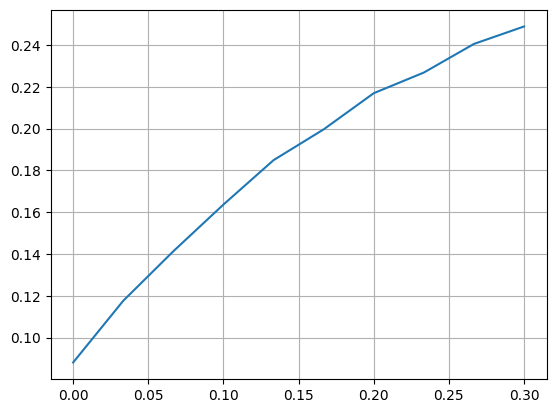

In [ ]:
y0, err0 = [], []

noise = np.linspace(0,0.3,10)

for i in noise:
    y, err, gatecount = iQPEnew_ry_testing(shots=1000, p = i)
    y0.append(y), err0.append(err)


plt.plot(noise, y0)
plt.grid()
plt.show()

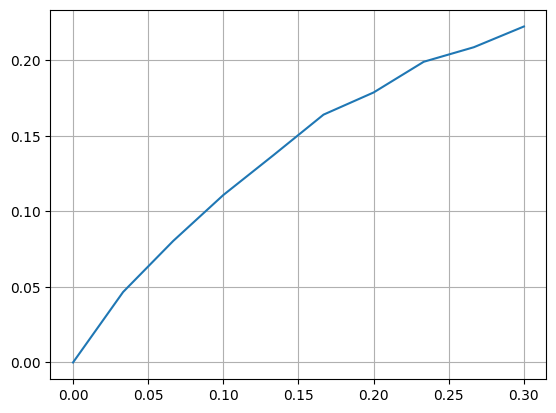

In [ ]:
y1, err1 = [], []

noise = np.linspace(0,0.3,10)

for i in noise:
    y, err, gatecount = iQPEnew7_ry_testing(shots=1000, p = i)
    y1.append(y), err1.append(err)


plt.plot(noise, y1)
plt.grid()
plt.show()